# Law of large numbers

This notebook is part of the computational resources for the Statistical Physics course at École Polytechnique. To return to the main repository, follow this link: [https://github.com/cossio/StatPhysCompX](https://github.com/cossio/StatPhysCompX).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

Let $X_1,\dots,X_n$ be independent and identically distributed copies of a real random variable $X$. Define the sample mean:

$$\overline{X_n} = \frac{1}{n} \sum_{i=1}^{n} X_i$$

Provided $\mathbb{E} X^{2}$ is finite, the weak law of large numbers says that $\overline{X_n}$ converges almost surely to $\mu=\mathbb{E}X$ as $N$ grows.

To make this more precise, we compute the variance of $\overline{X_n}$ as follows:

$$\mathbb{E}(\overline{X_n} - \mu)^{2} = \frac{1}{n^2} \sum_{i=1}^{n} \mathbb{E}(X_i-\mu)^2 = \frac{1}{n}\sigma^{2}$$

where $\sigma^{2} = \mathbb{E}(X-\mu)^2$ is the variance of $X$, which is finite by assumption. It follows that the variance of $\overline{X_n}$ decays to zero as $n\rightarrow\infty$, at a rate of $1/n$.

Let's consider a few examples. We will now sample $X$ from various distributions and verify that the sample mean indeed converges to the mean of $X$.

We will consider the Normal, Beta, T-student and Gamma distributions. The following plots show $n$ samples (in gray) of one of these distributions. The dashed blue line gives the mean of the original random variable, while the red line gives the sample mean $\overline{X_n}$ as a function of $n$. As predicted by the Law of Large Numbers, the sample mean approaches the mean of the random variable as $n$ increases.

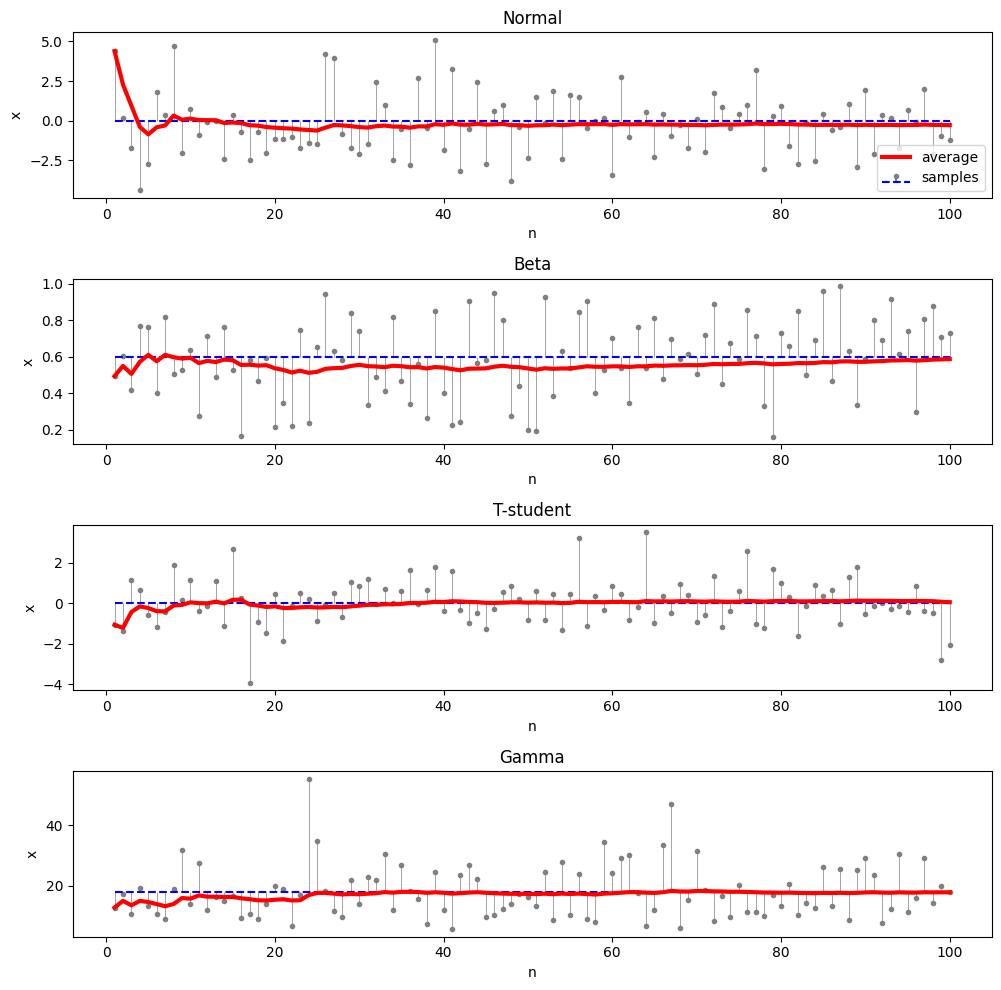

In [2]:
fig, axes = plt.subplots(4, 1, figsize=(10, 10))

distributions = [
    (stats.norm(0, 2), "Normal"),
    (stats.beta(3, 2), "Beta"),
    (stats.t(14), "T-student"),
    (stats.gamma(6, scale=3), "Gamma"),
]

for i, (dist, title) in enumerate(distributions):
    ax = axes[i]
    x = dist.rvs(100)
    n = np.arange(1, len(x) + 1)

    # Stem plot of samples
    markerline, stemlines, baseline = ax.stem(
        n, x, bottom=dist.mean(), label="samples"
    )
    plt.setp(stemlines, color="gray", linewidth=0.5)
    plt.setp(markerline, color="gray", markersize=3)
    plt.setp(baseline, linestyle="--", color="blue")

    # Running average
    ax.plot(n, np.cumsum(x) / n, color="red", linewidth=3, label="average")

    ax.set_title(title)
    ax.set_xlabel("n")
    ax.set_ylabel("x")
    if i == 0:
        ax.legend(loc="lower right")

plt.tight_layout()
plt.show()

Our proof above that the variance of the sample mean decays to zero as $n$ increases relies on the assumption that $\mathbb E X^2$ is finite. In fact, Kolmogorov proved a stronger version of the law of large numbers, assuming only that $\mathbb E |X|$ was finite.

But what happens if these assumptions are violated?

An interesting example is the Cauchy distribution, which has the density:

$$p(x) = \frac{1}{\pi} \frac{1}{1+x^2}$$

The Cauchy distribution does not have finite moments. In particular, $\mathbb E X^2$ and $\mathbb E |X|$ are both infinite. The assumptions behind the Law of Large Numbers do not hold anymore in this case. What happens if we sample a large number of random variates of the Cauchy distribution and compute the sample mean?

Let's repeat the above experiment, but this time using the Cauchy distribution.

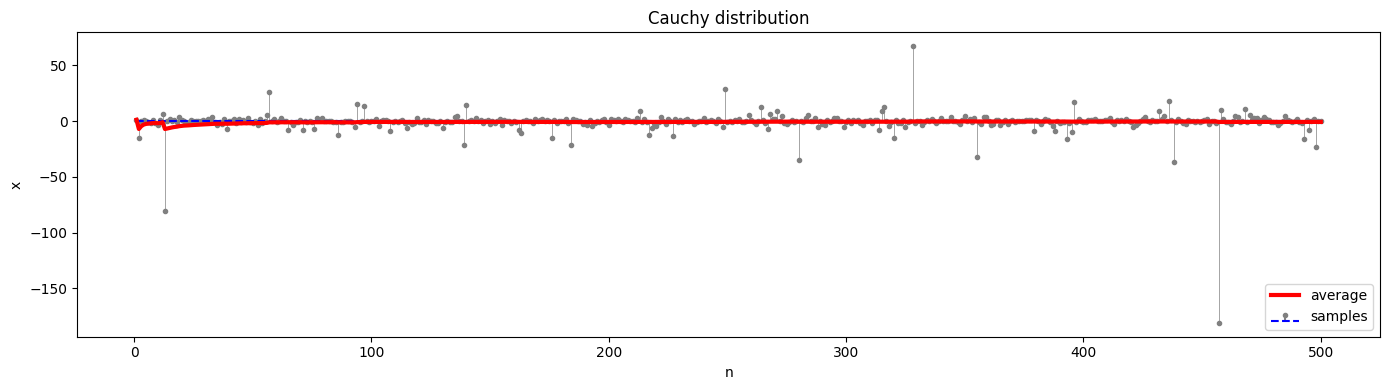

In [3]:
np.random.seed(10)
fig, ax = plt.subplots(figsize=(14, 4))

x = stats.cauchy.rvs(size=500)
n = np.arange(1, len(x) + 1)

markerline, stemlines, baseline = ax.stem(n, x, bottom=0, label="samples")
plt.setp(stemlines, color="gray", linewidth=0.5)
plt.setp(markerline, color="gray", markersize=3)
plt.setp(baseline, linestyle="--", color="blue")

ax.plot(n, np.cumsum(x) / n, color="red", linewidth=3, label="average")

ax.set_title("Cauchy distribution")
ax.set_xlabel("n")
ax.set_ylabel("x")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

Notice that the Cauchy distribution allows for extremely large fluctuations. In the previous plots, these large fluctuations are hiding the behavior of the sample mean. So let's zoom in the behavior of the sample mean alone, for increasing values of $n$. And let's compare that to one of the example distributions above for which the law of large numbers applied, e.g. the Normal distribution.

We now plot $n$ in a logarithmic scale to make the fluctuations of the sample mean apparent even at very large values of $n$.

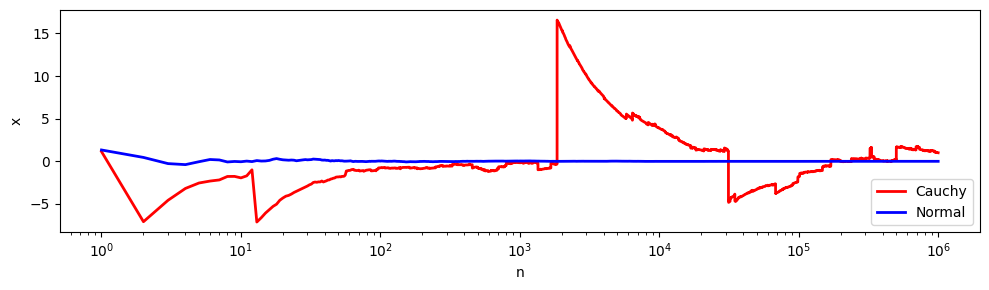

In [4]:
np.random.seed(10)
n = 10**6
x_cauchy = stats.cauchy.rvs(size=n)
x_normal = stats.norm.rvs(size=n)

fig, ax = plt.subplots(figsize=(10, 3))
indices = np.arange(1, n + 1)
ax.plot(indices, np.cumsum(x_cauchy) / indices, color="red", linewidth=2, label="Cauchy")
ax.plot(indices, np.cumsum(x_normal) / indices, color="blue", linewidth=2, label="Normal")
ax.set_xscale("log")
ax.set_xlabel("n")
ax.set_ylabel("x")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

In contrast to the normal distribution, the sample mean of the Cauchy distribution continues to exhibit significant fluctuations even for very large $n$.

In fact, one can show that for the Cauchy distribution, the sample mean follows the exact same distribution as the individual terms. To see this, note that the characteristic function of the Cauchy distribution is given by:

$$f(t) = \mathbb E e^{itX} = e^{-|t|}$$

Now consider the characteristic function of the sample mean:

$$\mathbb E e^{it\overline{X_n}}
= \mathbb E \exp\left\{ it \frac{1}{n}\sum_i X_i \right\}
= \prod_i \mathbb E \exp\left\{ it X_i/n \right\}
= f(t/n)^{n}$$

But we can verify that $f(t/n)^{n}=f(t)$ for the Cauchy distribution. Thus the sample mean $\overline{X_n}$ has the *same* Cauchy distribution as the individual $X_i$.

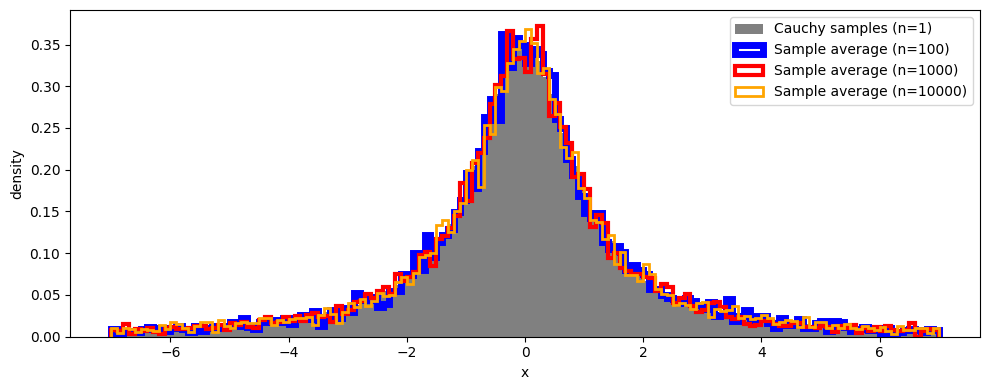

In [5]:
np.random.seed(10)
bins = np.arange(-7, 7.01, 0.1)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(stats.cauchy.rvs(size=10**6), bins=bins, density=True, color="gray",
        label="Cauchy samples (n=1)")
ax.hist(np.mean(stats.cauchy.rvs(size=(10**4, 100)), axis=1), bins=bins,
        density=True, histtype="step", linewidth=5, color="blue",
        label="Sample average (n=100)")
ax.hist(np.mean(stats.cauchy.rvs(size=(10**4, 1000)), axis=1), bins=bins,
        density=True, histtype="step", linewidth=3, color="red",
        label="Sample average (n=1000)")
ax.hist(np.mean(stats.cauchy.rvs(size=(10**4, 10000)), axis=1), bins=bins,
        density=True, histtype="step", linewidth=2, color="orange",
        label="Sample average (n=10000)")
ax.set_xlabel("x")
ax.set_ylabel("density")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

The Cauchy distribution exhibits a very different behavior than what one would expect from the law of large numbers!

Let's compare that to the distribution of the sample average of samples from a normal distribution. In contrast to the Cauchy case, the sample average of a Normal distribution quickly concentrates as $n$ increases.

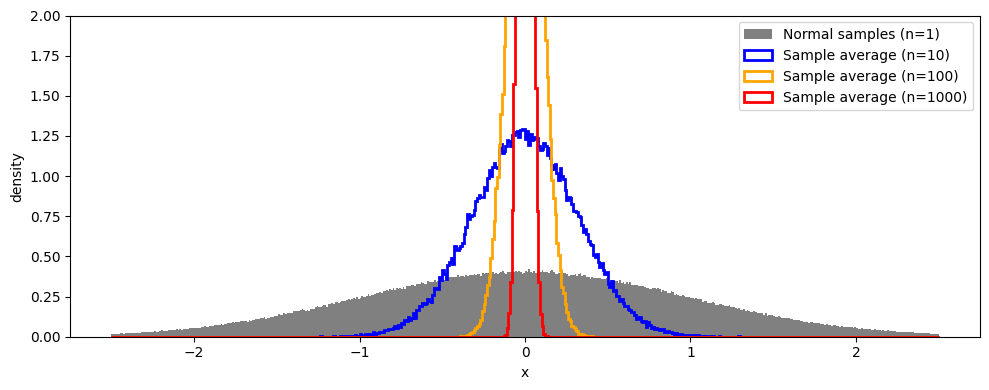

In [6]:
np.random.seed(10)
bins = np.arange(-2.5, 2.501, 0.01)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(stats.norm.rvs(size=10**6), bins=bins, density=True, color="gray",
        label="Normal samples (n=1)")
ax.hist(np.mean(stats.norm.rvs(size=(10**5, 10)), axis=1), bins=bins,
        density=True, histtype="step", linewidth=2, color="blue",
        label="Sample average (n=10)")
ax.hist(np.mean(stats.norm.rvs(size=(10**5, 100)), axis=1), bins=bins,
        density=True, histtype="step", linewidth=2, color="orange",
        label="Sample average (n=100)")
ax.hist(np.mean(stats.norm.rvs(size=(10**5, 1000)), axis=1), bins=bins,
        density=True, histtype="step", linewidth=2, color="red",
        label="Sample average (n=1000)")
ax.set_ylim(0, 2)
ax.set_xlabel("x")
ax.set_ylabel("density")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

The assumption that $X$ has bounded moments is indeed important for the validity of the LLN.